# DESI DR1 BGS Study

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *

In [2]:
#File names:
DIR = "Data DESI/"
outputDIR = DIR + "DESI Figures/" #to save figures
output_path = outputDIR + "DESI_DR1_QSO_" #common suffix to every figures
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC = Table.read(FILE_NGC)
SGC = Table.read(FILE_SGC)
NGC

TARGETID,NTILE,RA,DEC,PHOTSYS,Z,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_RF,BITWEIGHTS,PROB_OBS,WEIGHT_SYS,WEIGHT,WEIGHT_COMP,NX,WEIGHT_FKP
,,deg,deg,,,,,,,,,,,,
int64,int64,float64,float64,bytes1,float64,float64,float64,float64,int64[2],float64,float64,float64,float64,float64,float64
39627540901396635,1,159.24049207286527,-10.157311765959316,S,3.31353326666703,0.9747126436781609,1.0,0.9201403959075474,-1 .. -1,1.0,0.9201403959075474,0.7151357903795799,1.0,2.447879382530844e-06,0.9855253173679175
39627546840533492,1,158.63403463390813,-9.88258718935724,S,3.060108483008445,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,4.361994200942654e-06,0.9744955367198997
39627546844725753,1,158.73664897414398,-9.969939586395,S,2.541858124850623,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,1.0418531095218907e-05,0.9411665614806044
39627546848919608,1,158.95954631762686,-9.918830242767902,S,3.0791403351173816,0.9747126436781609,1.0126360654830933,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7740869234925823,1.0,4.361994200942654e-06,0.9744955367198997
39627546848920015,1,158.9834451646182,-9.940326955691557,S,2.1183562737081045,0.9747126436781609,1.0,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7644275667026461,1.0,1.872299525820529e-05,0.8990073391158527
39627546848921143,1,159.04734322663907,-9.942785828668026,S,1.3605934952612553,0.9747126436781609,1.0097328424453735,0.9885456821502936,-1 .. -1,1.0,0.9885456821502936,0.7757783261624652,1.0,2.5976158971824955e-05,0.8651589599263295
39627546848921614,1,159.07642532181774,-9.943104780472032,S,1.2436983617416455,0.9747126436781609,1.0,1.010660874479752,-1 .. -1,1.0,1.010660874479752,0.7854885694524114,1.0,2.5962721625169074e-05,0.8652193112619179
39627546848922860,1,159.1458229485638,-10.099793205114715,S,1.104592428700879,0.9747126436781609,1.0,1.0297096071899399,-1 .. -1,1.0,1.0297096071899399,0.8002932998859595,1.0,2.3079897197951834e-05,0.8783646105211212


## Data exoloration

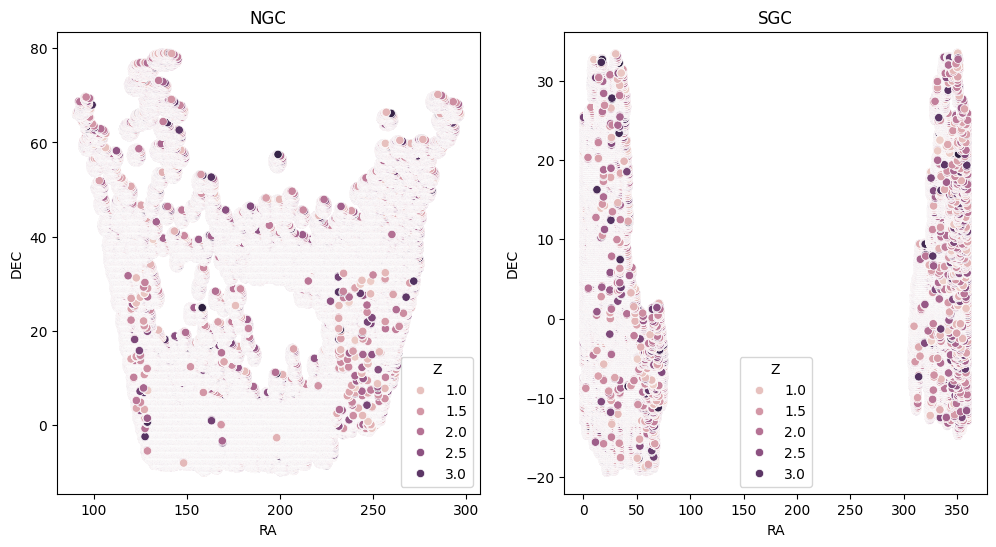

In [28]:
names = ["RA","DEC","Z"]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(NGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[0])
ax[0].set_title('NGC')
sns.scatterplot(SGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[1])
ax[1].set_title('SGC');

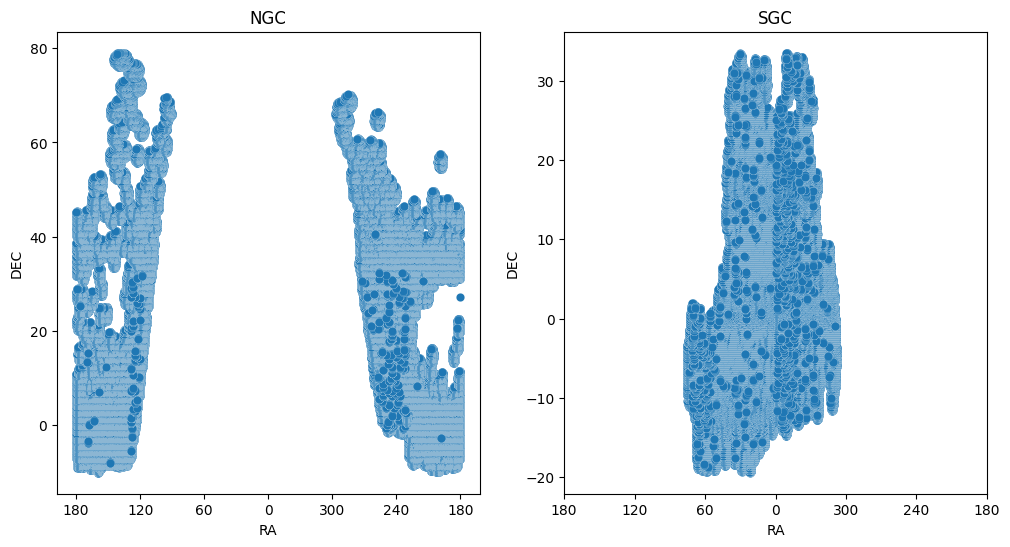

In [23]:
def recenter_RA(RA):
    return np.where(RA > 180,RA - 360, RA)

def plot_RADEC(RA, DEC, title='', RA_recenter=True, all_sky=True, **kwargs):
    if "figax" in kwargs.keys(): fig, ax = kwargs.pop("figax")
    else: fig, ax = plt.subplots()
    grid = kwargs.pop("grid", False)
    if RA_recenter: #make 360° correspond with 0°
        RA = RA.copy() #to not affect the data itself
        RA = recenter_RA(RA)
        RA_ticks = np.arange(-180, 201, 60)
        RA_labels = (RA_ticks + 360) % 360
    else:
        RA_ticks = np.arange(0, 361, 60)
        RA_labels = RA_ticks
    DEC_ticks = np.arange(-90, 91, 30)
    ax.scatter(RA, DEC, edgecolors='white', linewidths=0.1)
    if all_sky or RA_recenter:
        ax.set_xticks(RA_ticks)
        ax.set_xticklabels(RA_labels)
    if all_sky: ax.set_yticks(DEC_ticks)
    ax.invert_xaxis()
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC")
    if grid: ax.grid()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), all_sky=False)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), all_sky=False)

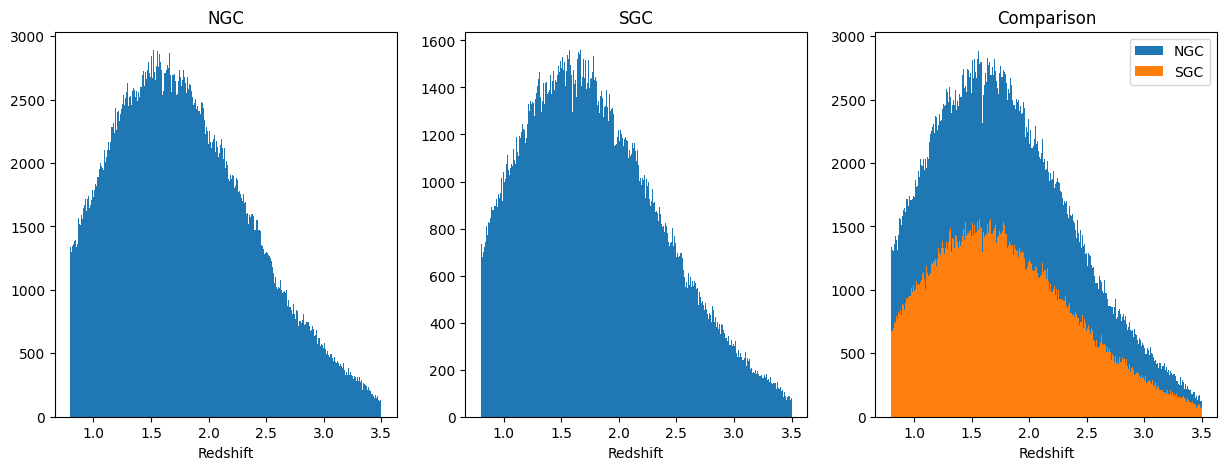

In [24]:
def histCompare_NS(col, xlabel, category=False, **kwargs):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    xscale = kwargs.pop('xscale', "linear")
    if category: #qualitative variables
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[0])
        ax[0].set_title("NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[1])
        ax[1].set_title("SGC")
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[2], label="NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[2], label="SGC")
        ax[2].set_title("Comparison")
    else: #quantitative variables
        get_hist(NGC[col], xlabel=xlabel, title="NGC", show=False, figax = (fig, ax[0]), **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="SGC", show=False, figax = (fig, ax[1]), **kwargs)
        get_hist(NGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="NGC", **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="SGC", **kwargs)
        ax[2].legend()
        ax[0].set_xscale(xscale)
        ax[1].set_xscale(xscale)
        ax[2].set_xscale(xscale)
    return fig, ax

histCompare_NS("Z", "Redshift", bins=500);

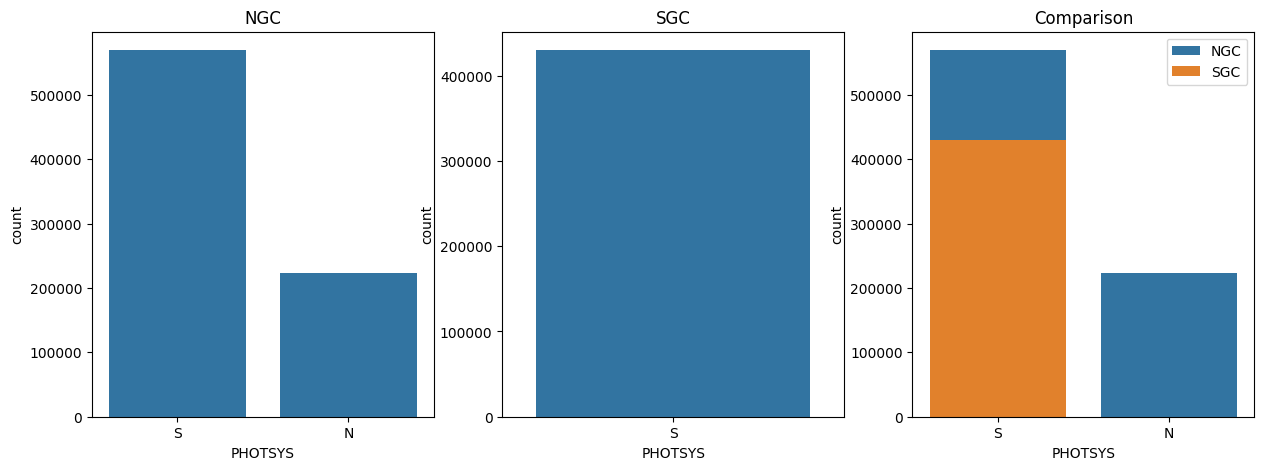

In [25]:
histCompare_NS("PHOTSYS", "PHOTSYS", category=True);

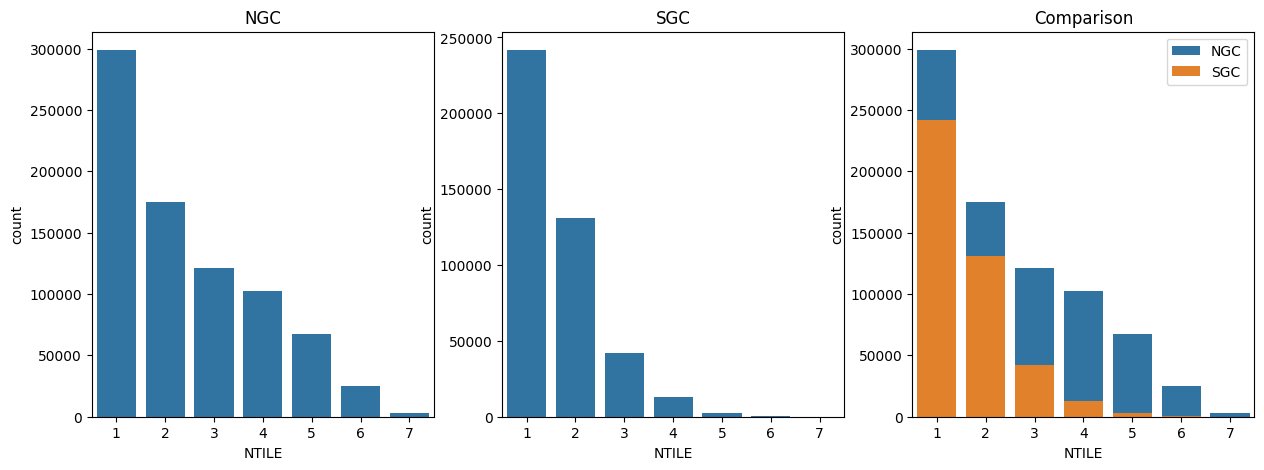

In [27]:
histCompare_NS("NTILE", "NTILE", category=True);

## Maps

In [3]:
NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
area_deg2 = hp.nside2pixarea(NSIDE, degrees=True)
print("Number of pixels = {}".format(NPIX))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


In [5]:
NSource_NGC = RADEC2NSource_Table(NSIDE, NGC, nest=True)
NSource_SGC = RADEC2NSource_Table(NSIDE, SGC, nest=True)
NSource_NGC_px, NSource_SGC_px = NSource_NGC/area_deg2, NSource_SGC/area_deg2

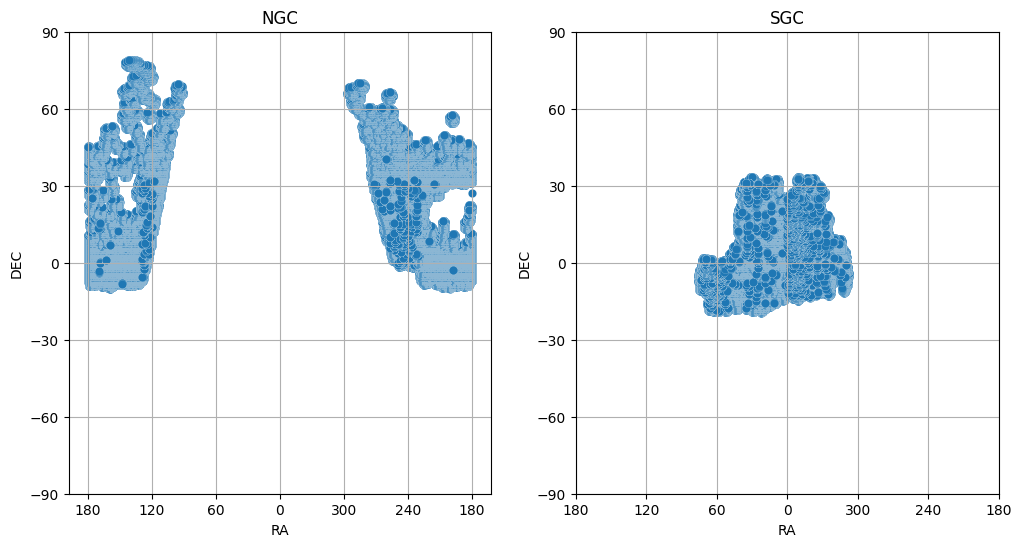

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), grid=True)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), grid=True)

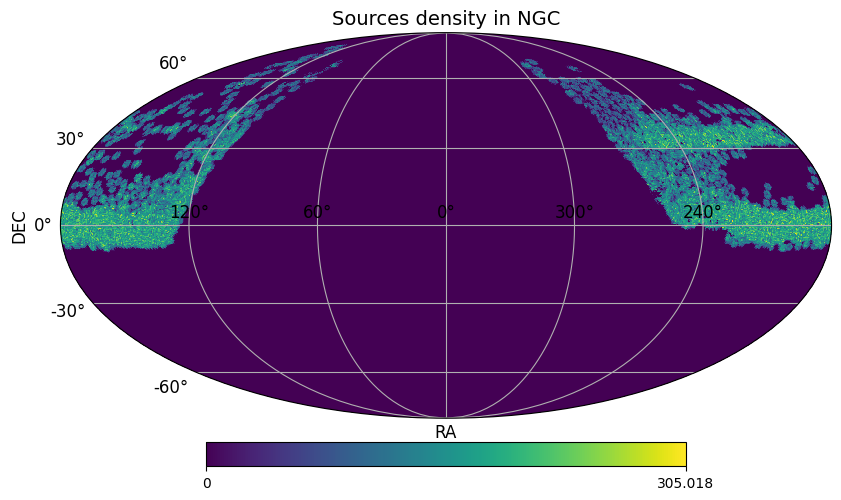

In [6]:
hp.projview(NSource_NGC_px, title="Sources density in NGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

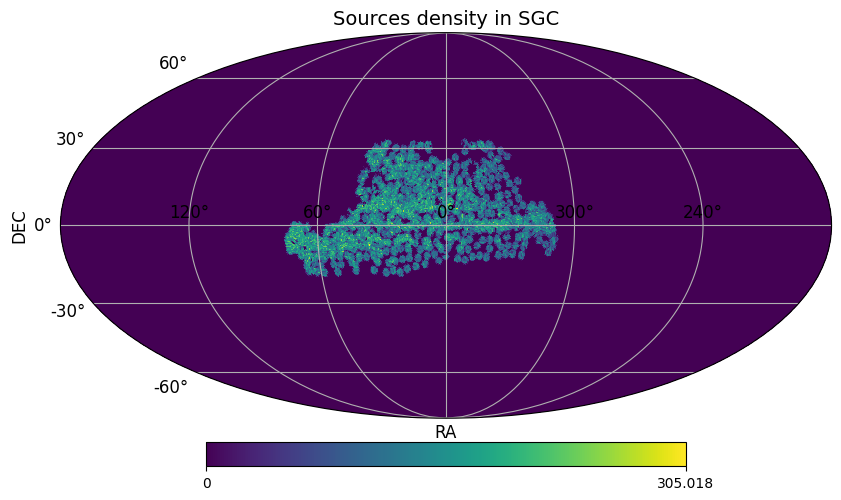

In [7]:
hp.projview(NSource_SGC_px, title="Sources density in SGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

Saving Source_Density_map in Data DESI/DESI Figures/DESI_DR1_QSO_Source_Density_map.pdf


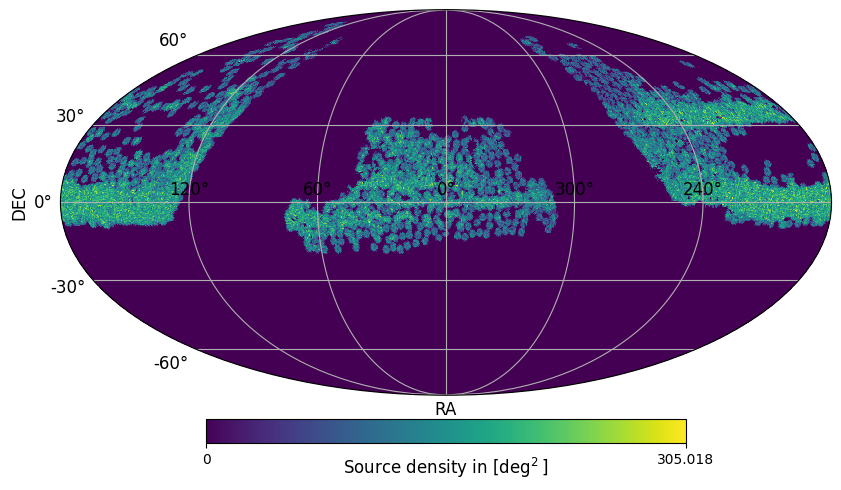

In [8]:
hp.projview(NSource_NGC_px+NSource_SGC_px, unit="Source density in $[\deg^2]$", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC")
get_savefig(plt, output_path, "Source_Density_map");

### Other analysis:

In [9]:
#addinf pixel number by source:
px_colname = "px_Nside{}".format(NSIDE)
NGC.add_column(hp.ang2pix(NSIDE, NGC['RA'], NGC['DEC'], lonlat=True, nest=True), name=px_colname)
NGC[px_colname].unit = None
SGC.add_column(hp.ang2pix(NSIDE, SGC['RA'], SGC['DEC'], lonlat=True, nest=True), name=px_colname)
SGC[px_colname].unit = None
NGC

TARGETID,NTILE,RA,DEC,PHOTSYS,Z,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_RF,BITWEIGHTS,PROB_OBS,WEIGHT_SYS,WEIGHT,WEIGHT_COMP,NX,WEIGHT_FKP,px_Nside128
,,deg,deg,,,,,,,,,,,,,
int64,int64,float64,float64,bytes1,float64,float64,float64,float64,int64[2],float64,float64,float64,float64,float64,float64,int64
39627540901396635,1,159.24049207286527,-10.157311765959316,S,3.31353326666703,0.9747126436781609,1.0,0.9201403959075474,-1 .. -1,1.0,0.9201403959075474,0.7151357903795799,1.0,2.447879382530844e-06,0.9855253173679175,106913
39627546840533492,1,158.63403463390813,-9.88258718935724,S,3.060108483008445,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,4.361994200942654e-06,0.9744955367198997,106915
39627546844725753,1,158.73664897414398,-9.969939586395,S,2.541858124850623,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,1.0418531095218907e-05,0.9411665614806044,106915
39627546848919608,1,158.95954631762686,-9.918830242767902,S,3.0791403351173816,0.9747126436781609,1.0126360654830933,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7740869234925823,1.0,4.361994200942654e-06,0.9744955367198997,106915
39627546848920015,1,158.9834451646182,-9.940326955691557,S,2.1183562737081045,0.9747126436781609,1.0,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7644275667026461,1.0,1.872299525820529e-05,0.8990073391158527,106915
39627546848921143,1,159.04734322663907,-9.942785828668026,S,1.3605934952612553,0.9747126436781609,1.0097328424453735,0.9885456821502936,-1 .. -1,1.0,0.9885456821502936,0.7757783261624652,1.0,2.5976158971824955e-05,0.8651589599263295,106915
39627546848921614,1,159.07642532181774,-9.943104780472032,S,1.2436983617416455,0.9747126436781609,1.0,1.010660874479752,-1 .. -1,1.0,1.010660874479752,0.7854885694524114,1.0,2.5962721625169074e-05,0.8652193112619179,106915
39627546848922860,1,159.1458229485638,-10.099793205114715,S,1.104592428700879,0.9747126436781609,1.0,1.0297096071899399,-1 .. -1,1.0,1.0297096071899399,0.8002932998859595,1.0,2.3079897197951834e-05,0.8783646105211212,106913


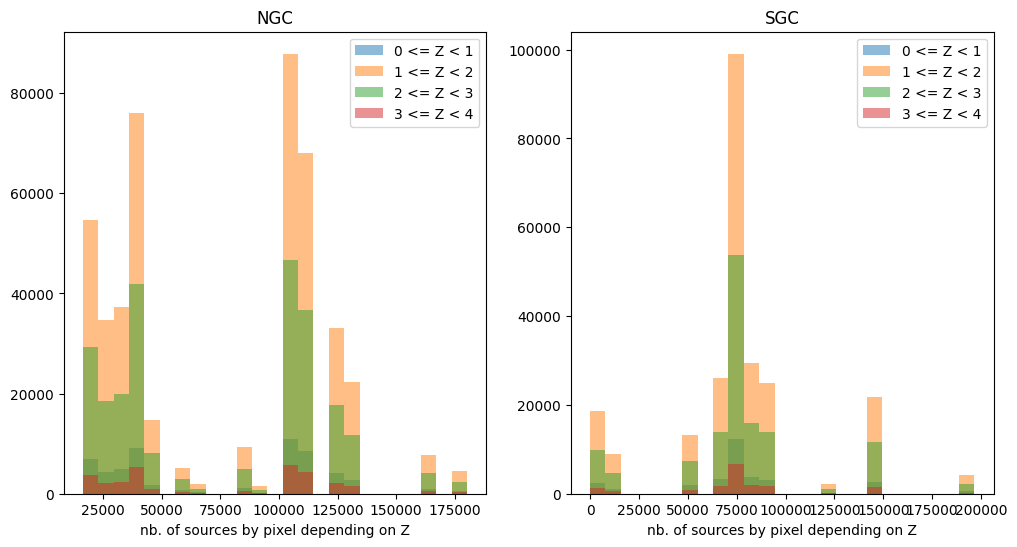

In [22]:
npins = 4
Z_lim = (np.arange(0, npins, 1).reshape([-1,1]))
masks_NGC = (NGC["Z"] >= Z_lim) & (NGC["Z"] < Z_lim+1)
masks_SGC = (SGC["Z"] >= Z_lim) & (SGC["Z"] < Z_lim+1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
xlabel = "nb. of sources by pixel depending on Z"
bins = 25
for i in range(npins):
    label = "{} <= Z < {}".format(np.round(Z_lim[i, 0], 1), np.round(Z_lim[i, 0]+1, 1))
    ax[0].hist(NGC[px_colname][masks_NGC[i]], label=label, bins=bins, alpha=0.5)
    ax[0].set_title("NGC")
    ax[0].set_xlabel(xlabel)
    ax[0].legend()
    ax[1].hist(SGC[px_colname][masks_SGC[i]], label=label, bins=bins, alpha=0.5)
    ax[1].set_title("SGC")
    ax[1].set_xlabel(xlabel)
    ax[1].legend()